In [33]:
#importiamo tutte le librerie che ci servono
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler

import warnings as wr
wr.filterwarnings('ignore')

In [34]:
#carichiamo il file csv creando un dataframe
df = pd.read_csv('breast_ cancer_data.csv')


In [35]:
#diamo uno sguardo veloce delle prime 5 righe 
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [36]:
#guardiamo le ultime righe 
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [37]:
#vediamo quanto è grande il df 
df.shape

(569, 33)

In [38]:
#vediamo l'elenco delle colonne
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [39]:
#visualizziamo dei dati statistici
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [40]:
#vediamo se ci sono dati null
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [41]:
#quanti tumori sono benigni(B)) e quanti maligni(M) ?

tipo_tumore = df['diagnosis'].value_counts()
print(tipo_tumore)

diagnosis
B    357
M    212
Name: count, dtype: int64


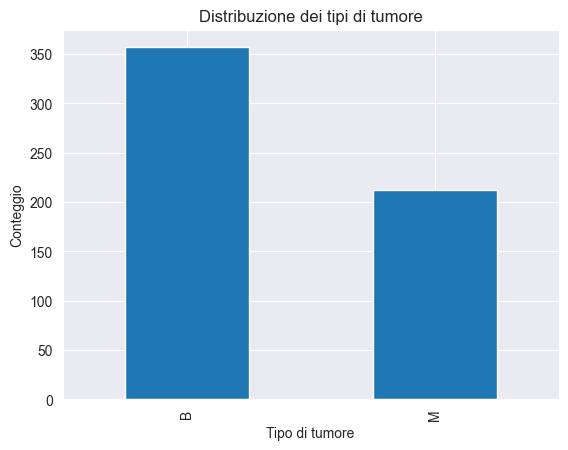

In [42]:
#e rendiamo il dato in forma visiva

tipo_tumore.plot(kind='bar')
plt.xlabel('Tipo di tumore')
plt.ylabel('Conteggio')
plt.title('Distribuzione dei tipi di tumore')
plt.show()

In [43]:
#rendiamo la colonna in 0 e 1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})


In [44]:
cols = df[['texture_mean','texture_se','symmetry_se',
       'fractal_dimension_se', 'radius_worst',]]

In [45]:
'''#viene utilizzato l'intero DF
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()'''

'#viene utilizzato l\'intero DF\nsns.set_style("darkgrid")\n\nnumerical_columns = df.select_dtypes(include=["int64", "float64"]).columns\n\nplt.figure(figsize=(14, len(numerical_columns) * 3))\nfor idx, feature in enumerate(numerical_columns, 1):\n    plt.subplot(len(numerical_columns), 2, idx)\n    sns.histplot(df[feature], kde=True)\n    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")\n\nplt.tight_layout()\nplt.show()'

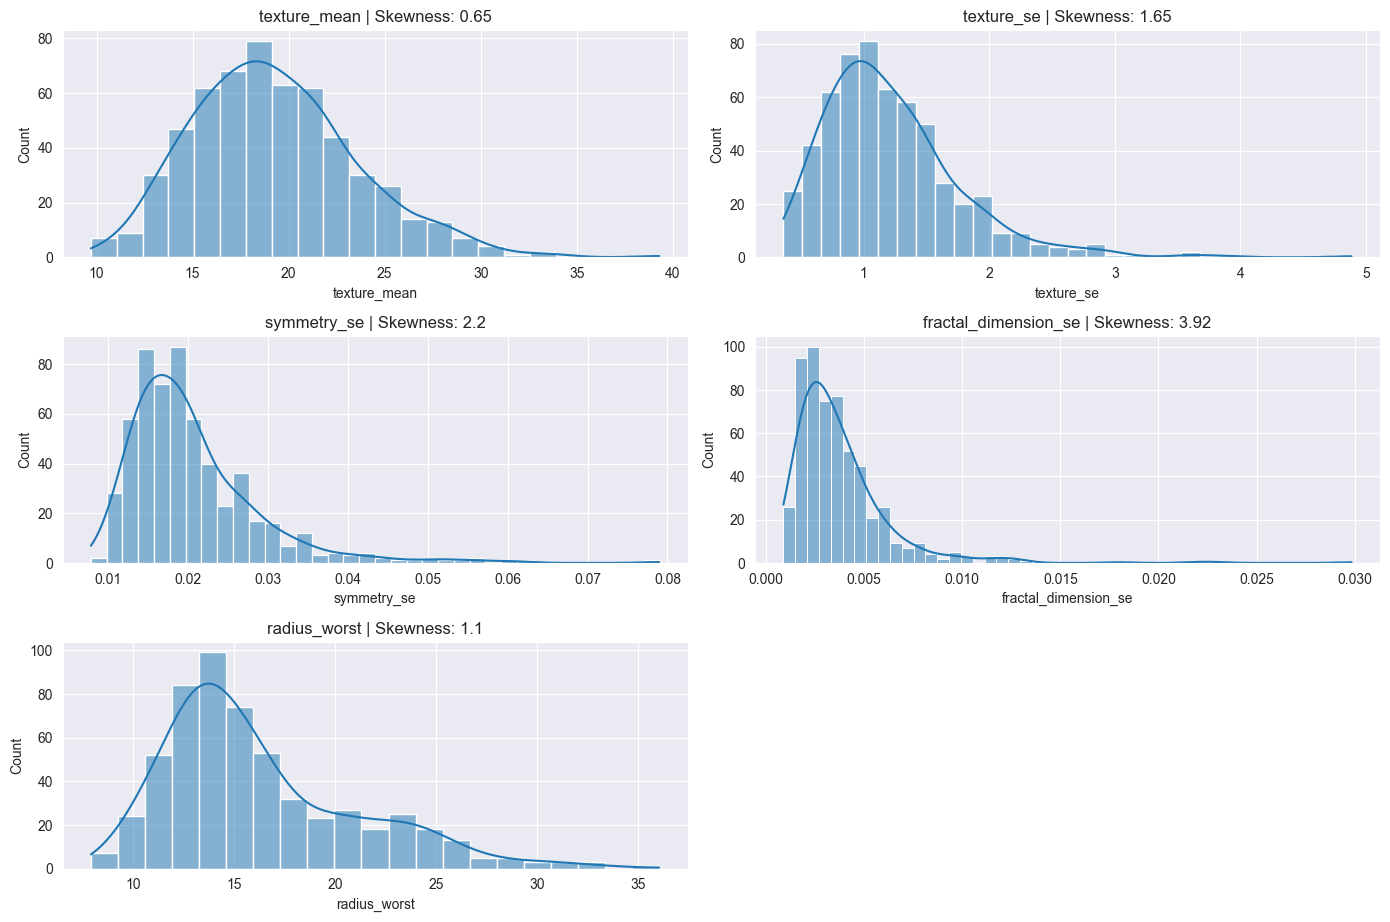

In [46]:
#vengono utilizzate solo le colonne ritenute utili
sns.set_style("darkgrid")

numerical_columns = cols.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

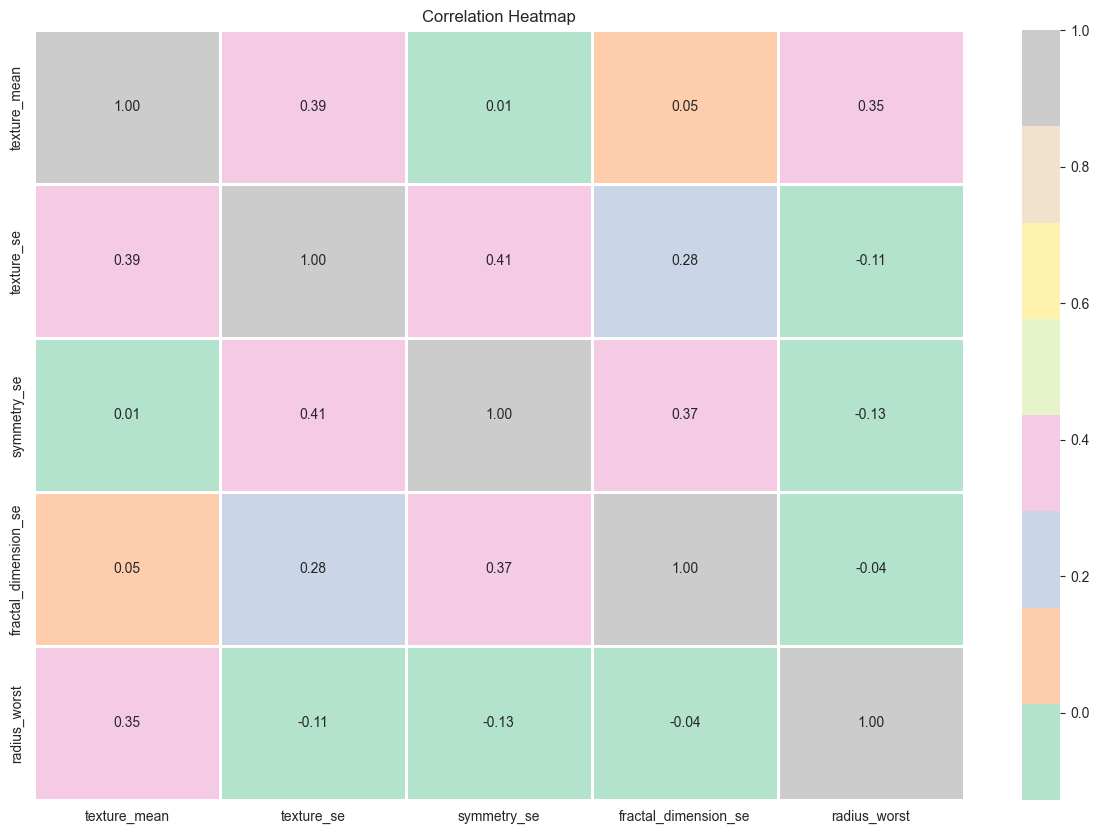

In [47]:
#Correlation matrix

plt.figure(figsize=(15, 10))

sns.heatmap(cols.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

<Figure size 1000x600 with 0 Axes>

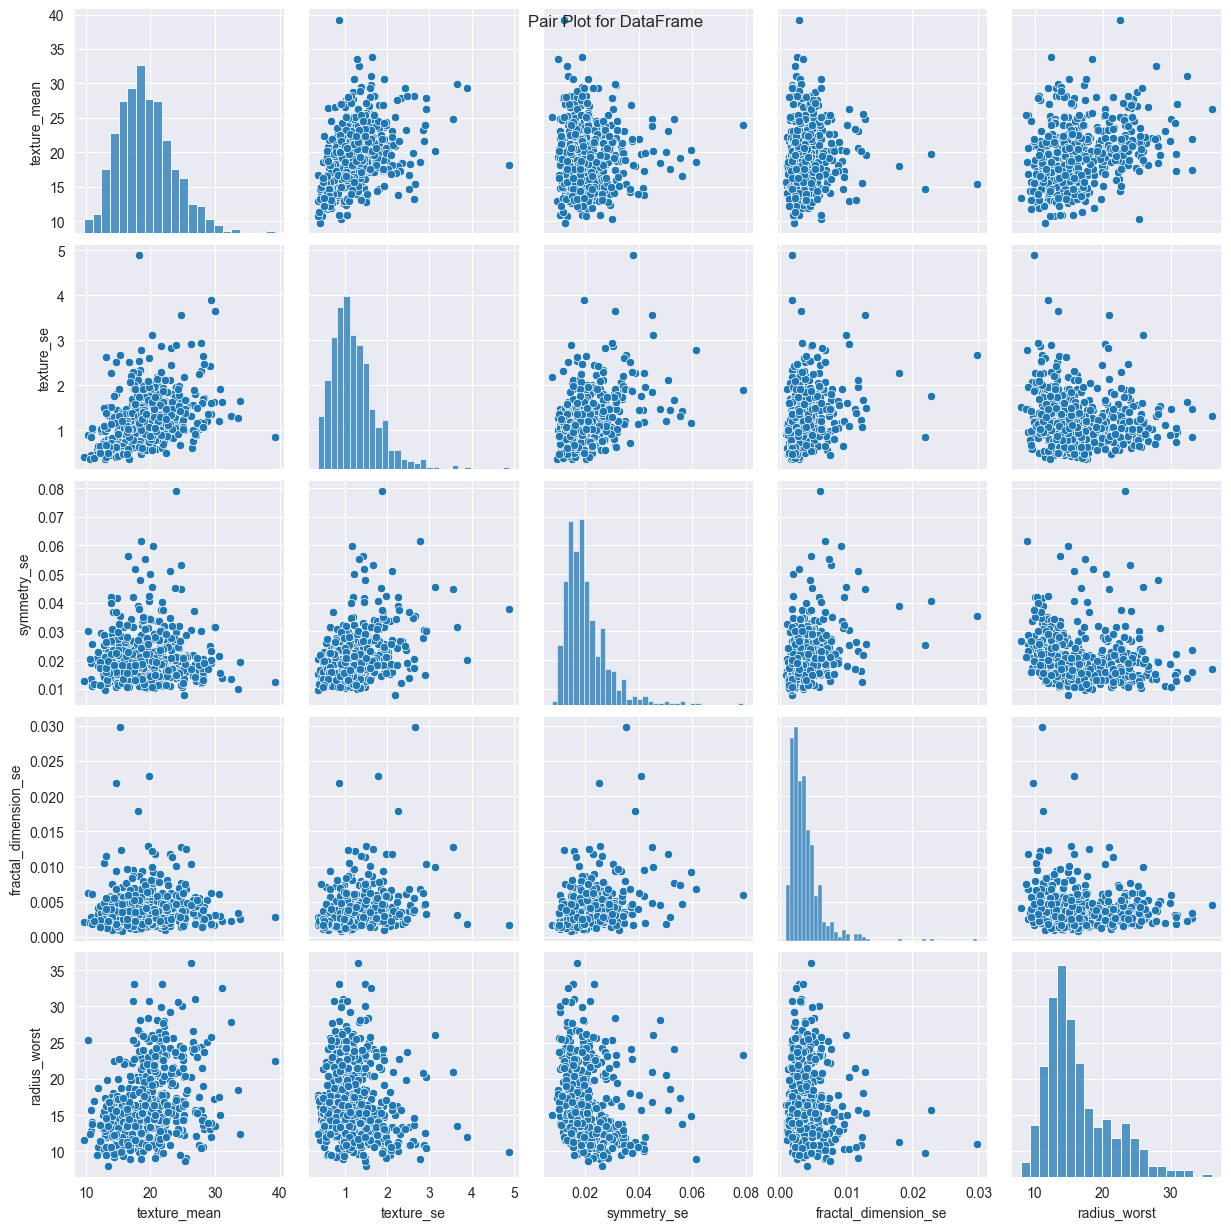

In [48]:
#farlo partire impiega molto tempo

plt.figure(figsize=(10, 6))

sns.pairplot(cols)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

In [49]:
#iniziamo con il dire cosa sono x e y dove y è il target e la x sono le altre variabili

feature_cols = ['texture_mean','texture_se','symmetry_se',
       'fractal_dimension_se', 'radius_worst']

x = df[feature_cols]
y = df.diagnosis


In [50]:
# iniziamo la fase di traning del modello (il test_size con un float indica la percentuale da usare , l'intero indica le righe da usare)
#diamo a random_state un valore in modo da creare il seed

x_train , x_test , y_train , y_test , = train_test_split(x, y , test_size= 0.25, random_state= 42)

In [51]:
#passiamo ad allenare il modello e  fare la predizione

logreg = LogisticRegression(random_state=42)

#fase di allenamento
logreg.fit(x_train , y_train)

#passiamo alla fase di predizione e la probabilità

y_pred = logreg.predict(x_test)
y_prob = logreg.predict_proba(x_test)


np.set_printoptions(suppress=True)  # disattiva la notazione scientifica che non permette di visualizzare correttamente le %


#y_prob_percent = np.round(y_prob * 100, 2)

print(y_pred)
print('_______________________________________________________________________')
print('Probabilità B o M' , y_prob*100)





[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0]
_______________________________________________________________________
Probabilità B o M [[88.96264837 11.03735163]
 [ 0.00696993 99.99303007]
 [ 5.2703765  94.7296235 ]
 [99.02324626  0.97675374]
 [99.77616666  0.22383334]
 [ 0.00034219 99.99965781]
 [ 0.0002688  99.9997312 ]
 [ 6.7683065  93.2316935 ]
 [89.53954086 10.46045914]
 [91.78838565  8.21161435]
 [75.1588434  24.8411566 ]
 [ 2.58733914 97.41266086]
 [66.24455032 33.75544968]
 [13.93835179 86.06164821]
 [99.45226893  0.54773107]
 [ 0.27906013 99.72093987]
 [91.42431509  8.57568491]
 [99.8630685   0.1369315 ]
 [99.99860135  0.00139865]
 [ 0.01438474 99.98561526]
 [73.66058498 26.33941502]
 [97.9036864   2.0963136 ]
 [ 0.00118565 99.99881435

In [52]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.951048951048951


Text(0.5, 23.52222222222222, 'Predicted diagnosis')

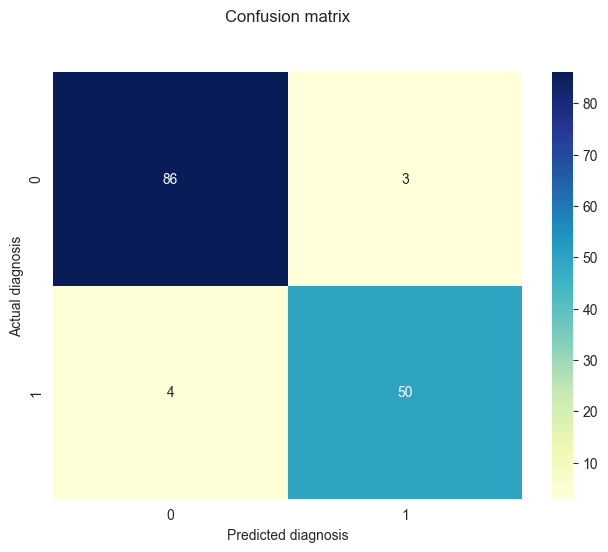

In [53]:
# import the metrics class


cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# creiamo  heatmap per mostrare il margine di errore del modello
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual diagnosis')
plt.xlabel('Predicted diagnosis')

In [54]:
target_names = ['Diagnosis B', 'Diagnosis M']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

 Diagnosis B       0.96      0.97      0.96        89
 Diagnosis M       0.94      0.93      0.93        54

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



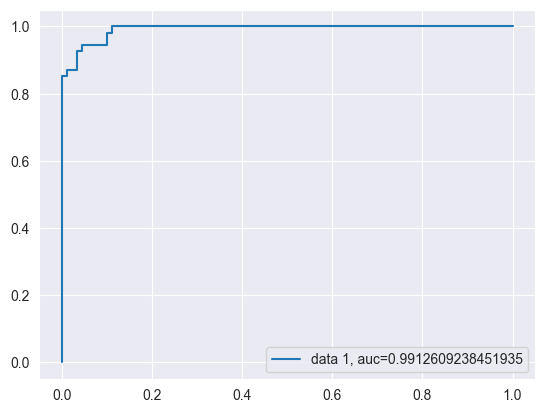

In [55]:
y_pred_proba = logreg.predict_proba(x_test)[::,1]
y_test_numeric = y_test.astype(int)
fpr, tpr, _ = metrics.roc_curve(y_test_numeric,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [64]:
x_train_2 = x_train.copy() 

scaler = StandardScaler()

x_train_standardized = scaler.fit_transform(x_train_2)

In [65]:
logreg_2 = LogisticRegression(random_state=42)

#fase di allenamento
logreg_2.fit(x_train_standardized , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Text(0.5, 1.0, 'Peso delle variabili nel modello')

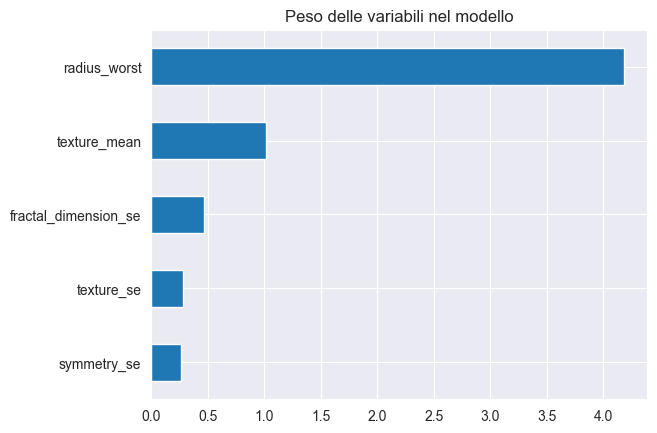

In [72]:
# visualizziamo il peso delle variabili nel modello
importance = pd.Series(logreg_2.coef_[0], index=feature_cols)
importance.abs().sort_values().plot(kind='barh')
plt.title('Peso delle variabili nel modello')

<Axes: xlabel='diagnosis', ylabel='texture_mean'>

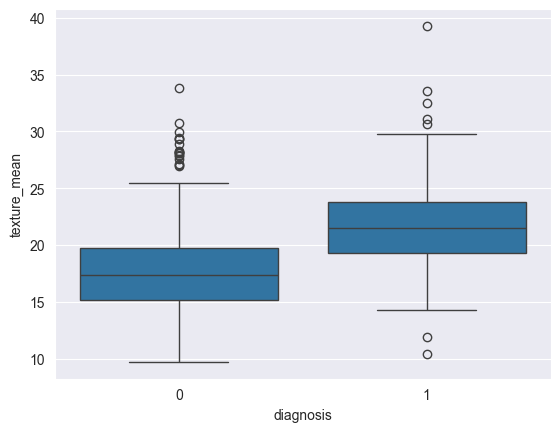

In [57]:
#Boxplot for diagnosis and texture_mean

sns.boxplot(x='diagnosis', y= 'texture_mean', data=df)

<Axes: xlabel='diagnosis', ylabel='texture_se'>

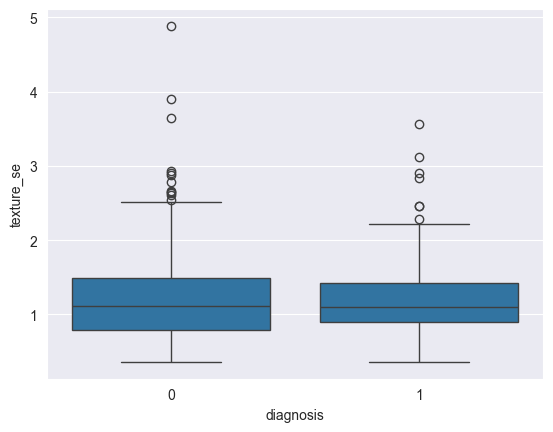

In [58]:
#Boxplot for diagnosis and texture_se

sns.boxplot(x='diagnosis', y= 'texture_se', data=df)

<Axes: xlabel='diagnosis', ylabel='symmetry_se'>

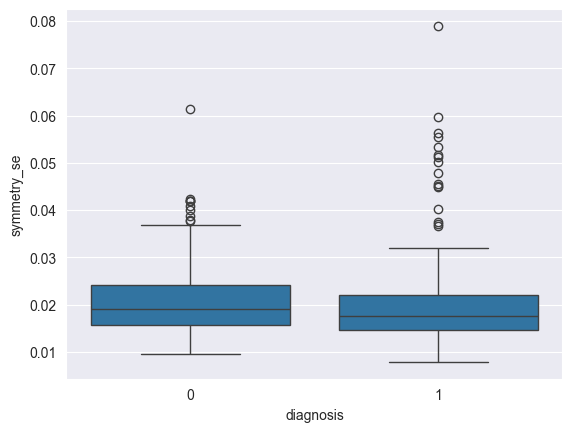

In [59]:
#Boxplot for diagnosis and symmetry_se

sns.boxplot(x='diagnosis', y= 'symmetry_se', data=df)

<Axes: xlabel='diagnosis', ylabel='fractal_dimension_se'>

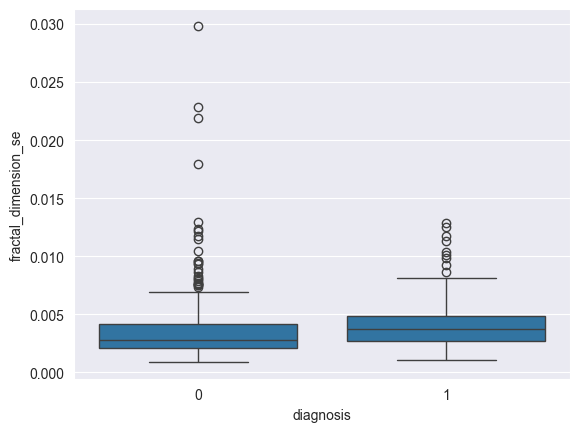

In [60]:
#Boxplot for diagnosis and fractal_dimension_se

sns.boxplot(x='diagnosis', y= 'fractal_dimension_se', data=df)

<Axes: xlabel='diagnosis', ylabel='radius_worst'>

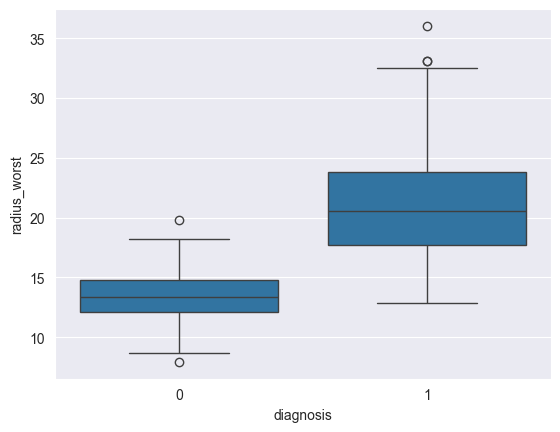

In [61]:
#Boxplot for diagnosis and radius_worst

sns.boxplot(x='diagnosis', y= 'radius_worst', data=df)